# Tutorial 3: Visium HD integration with STUltra

This notebook follows the workflow into steps:
1) Load and preprocess each Visium HD section
2) Build spatial graphs and concatenate
3) Train STUltra
4) Embed, cluster, and visualize
5) Save results

Notes:
- The dataset root and section IDs must match your on-disk folder names.
- Key parameters (graph radius, HVGs, training epochs, alpha) are documented in the steps below.
- If you change the data resolution (e.g., 008um), adjust graph parameters accordingly.

In [ ]:
import os
import warnings

import numpy as np
import anndata as ad
import scanpy as sc
import torch
import matplotlib.pyplot as plt

import STUltra

warnings.filterwarnings("ignore")
os.environ["R_USER"] = "/usr/lib/R"

## Step 0: Configure input/output

Set the dataset root (`base_path`), which should contain folders like:
`Human_Colon_Cancer_<section_id>/binned_outputs/square_008um/`.

`section_ids` should match the available section folder suffixes (e.g., `P1`, `P2`).
Use `subsample_fraction < 1.0` to downsample spots for quick tests.

### Data Preparation

This step downloads the example Visium HD dataset (may take a while).
Run the command below in your terminal or notebook to start downloading:

```
! bash download_Visium_HD_HCC.sh
```
Downloading this dataset can take a long time. We recommend running the download command in your terminal for better performance.

If you've already prepared the data, you can skip this step.

In [ ]:
base_path = "/data1/st_data/Visium_HD_Human_Colon_Cancer"
# Each ID maps to a folder like Human_Colon_Cancer_<ID>/
section_ids = ["P1", "P2"]


# Match the script's device selection (change cuda index if needed)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print("device:", device)
print("sections:", section_ids)

## Step 1: Load and preprocess each section

This step:
- Reads a Visium HD section with `scanpy.read_visium`
- Filters low-count genes (`min_cells`)
- Optionally subsamples spots
- Builds the spatial graph (`rad_cutoff`, `k_cutoff`, `model`)
- Normalizes counts and selects HVGs (`n_top_genes`)

Parameter tips:
- `min_cells`: increase to drop more low-coverage genes.
- `rad_cutoff`: physical radius for edges (depends on spot spacing).
- `k_cutoff`: kNN fallback, keep small for sparse graphs.
- `n_top_genes`: 2k is common; reduce for memory.

In [ ]:
def load_section(section_id: str):
    path = (
        f"{base_path}/Human_Colon_Cancer_{section_id}/"
        "binned_outputs/square_008um/"
    )
    adata = sc.read_visium(path, library_id=section_id)
    adata.var_names_make_unique(join="++")

    # Filter genes expressed in too few spots
    print("Before filtering:", adata.shape)
    sc.pp.filter_genes(adata, min_cells=50)
    print("After filtering:", adata.shape)

    # Make spot names unique across sections
    adata.obs_names = [x + "_" + section_id for x in adata.obs_names]

    # Build spatial graph
    # rad_cutoff: radius (um-scaled) for neighborhood edges
    # k_cutoff: kNN fallback when radius has few neighbors
    STUltra.Cal_Spatial_Net(adata, rad_cutoff=50, k_cutoff=3, model="KNN")

    # Normalize and select HVGs
    # target_sum=1e4 is standard library size normalization
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=2000)
    adata = adata[:, adata.var["highly_variable"]]

    return adata

## Step 2: Concatenate sections and spatial graphs

We store each section and its adjacency in lists, then concatenate:
- `label="slice_name"` keeps section identity
- `batch_name` is used for batch-aware training
- `edgeList` is the concatenated spatial graph used by STIntg

In [ ]:
Batch_list = []
adj_list = []

for section_id in section_ids:
    print(f"Processing slice: {section_id}")
    adata_section = load_section(section_id)
    Batch_list.append(adata_section)
    # Each section stores its adjacency in adata.uns["adj"]
    adj_list.append(adata_section.uns["adj"])

# Concatenate all sections into a single AnnData
adata_concat = ad.concat(Batch_list, label="slice_name", keys=section_ids)

# Extract batch name prefix for batch-aware training
adata_concat.obs["batch_name"] = (
    adata_concat.obs["slice_name"].str.split("_").str[0]
)
adata_concat.obs["batch_name"] = adata_concat.obs["batch_name"].astype("category")
print("adata_concat.shape:", adata_concat.shape)

# Merge adjacency lists into a single edgeList
adata_concat.uns["edgeList"] = STUltra.adj_concat(adj_list)

## Step 3: Train STUltra (Batch Training Parameters)

The following parameters mainly control the "batch alignment + representation learning" process:
- `knn_neigh`: Number of kNN neighbors for feature graph construction (not for spatial graph); affects local structure preservation.
- `alpha`: Batch alignment loss weight; larger values emphasize alignment across batches.
- `num_batch`: The number of batches, should match the number of categories in `batch_name`.
- `pretrain_epochs` / `n_epochs`: Number of pre-training and main training epochs; can be reduced for large datasets.
- `spatial_net_args`: Parameters for spatial graph construction (`rad_cutoff`/`k_cutoff`/`model`); should match the graph setup from the previous step.

In [ ]:
spatial_net_args = {
    "rad_cutoff": 50,
    "k_cutoff": 3,
    "model": "KNN",
    "verbose": True,  # Controls batch output during processing; set to True for detailed logs
}

adata_concat = STUltra.train(
    adata_concat,
    verbose=True,
    knn_neigh=100,
    alpha=5,
    device=device,
    batch_data=True,
    spatial_net_args=spatial_net_args,
    num_batch=3, 
    pretrain_epochs=200,
    n_epochs=400,
)

## Step 4: Embed, cluster, and visualize

We use the learned embedding (`use_rep="STUltra"`) for neighbors, UMAP, and clustering.
Louvain resolutions control cluster granularity.

In [ ]:
sc.pp.neighbors(adata_concat, use_rep="STUltra")
sc.tl.umap(adata_concat)
sc.tl.louvain(adata_concat, resolution=0.4, key_added="louvain_0.4")


/home/user/anaconda3/envs/stClinic/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/user/anaconda3/envs/stClinic/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


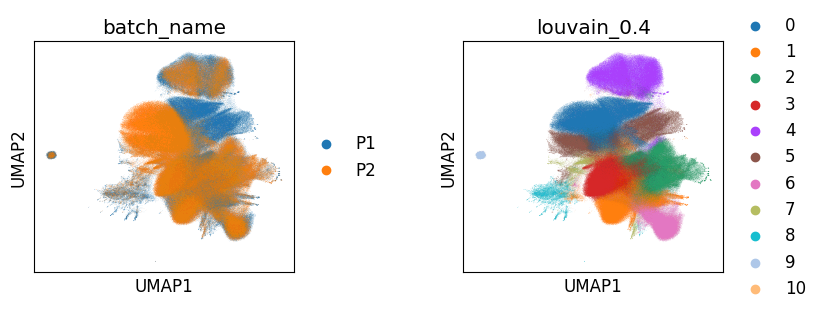

In [5]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (3, 3)
plt.rcParams['font.size'] = 12

sc.pl.umap(adata_concat, color=["batch_name", "louvain_0.4"], ncols=2, wspace=0.5, show=True)

plotting cluster 0
plotting cluster 1


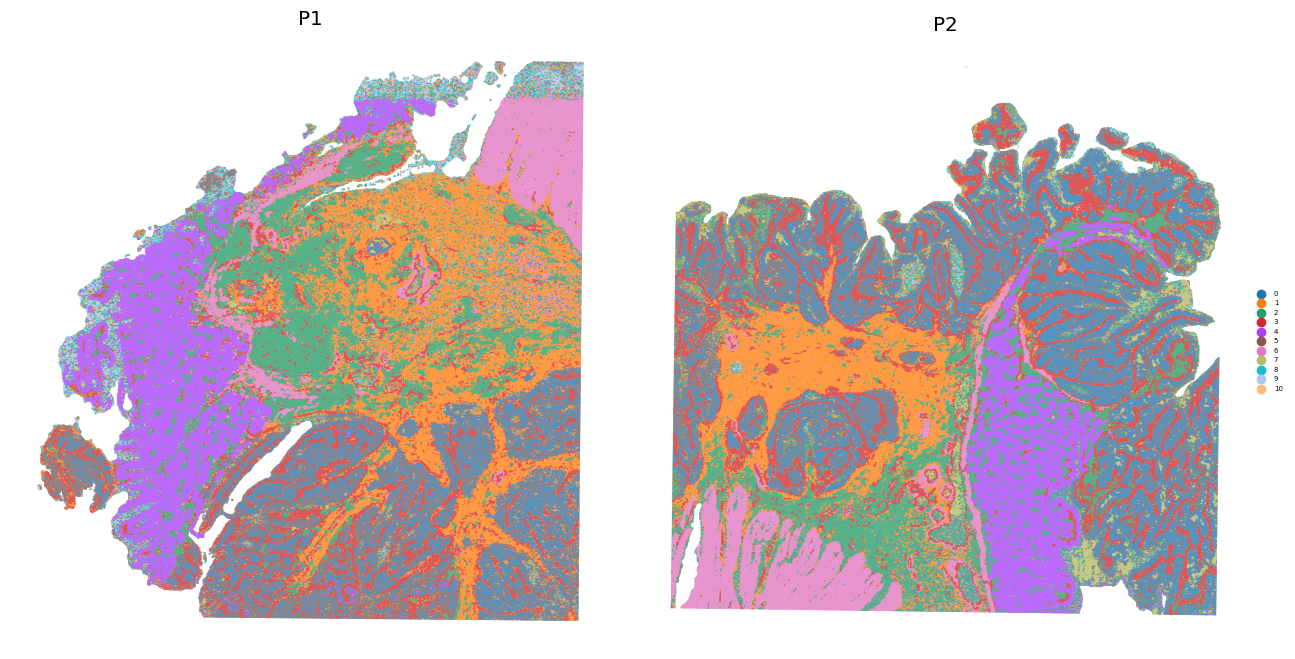

In [6]:

Batch_list = []
section_ids = adata_concat.obs['batch_name'].unique()
for ss in range(len(section_ids)):
    adata_section = adata_concat[adata_concat.obs['batch_name'] == section_ids[ss]]
    Batch_list.append(adata_section)

spot_size = 6
title_size = 10
fig, ax = plt.subplots(1, len(section_ids), figsize=(len(section_ids)*8, 8), gridspec_kw={'wspace':0.05, 'hspace': 0.1})    
for i, i_id in enumerate(section_ids):
    print(f'plotting cluster {i}')
    _sc_0 = sc.pl.spatial(Batch_list[i], img_key=None, color="louvain_0.4", 
                    title=i_id, size=spot_size, legend_fontsize=5, 
                show=False, frameon=False, ax=ax[i], spot_size=spot_size, legend_loc='right margin',)
    if i == 0:
        ax[i].legend().remove()
# plt.savefig(f'{save_dir}/VisiumHD_basis.png', bbox_inches='tight',dpi=300)      
plt.show()

## Step 5: Save output

`edgeList` can be large; remove it before saving if not needed for later.

In [ ]:
# Remove large adjacency list before saving
if "edgeList" in adata_concat.uns:
    del adata_concat.uns["edgeList"]

# Name reflects alpha=8 in training
out_path = f"{base_path}/crc_integrated.h5ad"
adata_concat.write(out_path)
print("Saved:", out_path)